## Załadowanie bibliotek

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import zscore

In [142]:
# pozbycie się notacji naukowej
np.set_printoptions(suppress=True)

### Funkcja MNK

In [143]:
def linear_regression(data, y):
    np.set_printoptions(suppress=True)
    data = np.asarray(data.values)
    y = np.asarray(y).reshape(-1,1)
    t = data.shape[0]
    ones = np.ones(t)
    X = np.column_stack([ones, data])
    beta_head = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(y))
    s2 = (1/(t-len(beta_head))) * (y - X.dot(beta_head)).T.dot(y- X.dot(beta_head))
    s = np.sqrt(s2)
    y_head = X.dot(beta_head)
    R2 = np.sum((y_head - np.mean(y_head))**2) / np.sum((y - np.mean(y))**2)
    R2_correct = 1 - (1-R2)*((t-1)/(t-X.shape[1]))
    V = np.sqrt(s2) / np.mean(y) * 100
    kow_matrix = s2 * np.linalg.inv((X.T.dot(X)))
    db = np.sqrt(np.diag(kow_matrix))

    return {
        "beta_head": beta_head.round(4),
        "s2": s2,
        "s": s,
        "y_head": y_head,
        "R2": R2,
        "R2_corrected": R2_correct,
        "V": V,
        "kow_matrix": kow_matrix,
        "db": db
    }

### Nazwy i jednostki zmiennych: 
#### Zmienna objaśniana (zależna):
*	Y - Oczekiwana długość życia w momencie urodzenia (wyrażona w latach).
#### Zmienne objaśniające (niezależne):
*	X1 - Produkt Krajowy Brutto per capita (wyrażony w tys. EUR).
*	X2 - Udział wydatków na ochronę zdrowia w PKB (wyrażone w %).
*	X3 - Odsetek populacji palącej papierosy (wyrażony w %).
*	X4 - Odsetek populacji w wieku 15-64 lata posiadającej wyższe wykształcenie (wyrażony w %). 


### Wczytanie danych

In [144]:
data = pd.read_csv('../data/dane_finalne.csv', sep=';', decimal=',')
print(data.head())

    country     Y     X1         X2  X3    X4
0  Bulgaria  75.8  14.66   7.933980  21  26.7
1   Czechia  79.9  29.33   8.421847  37  23.5
2   Denmark  81.8  62.91   9.594595  23  35.5
3   Germany  81.1  50.66  11.673909  14  28.7
4   Estonia  79.1  28.08   7.438437  24  36.0


### wizualizacja danych matrix scatter plot, korelacje 

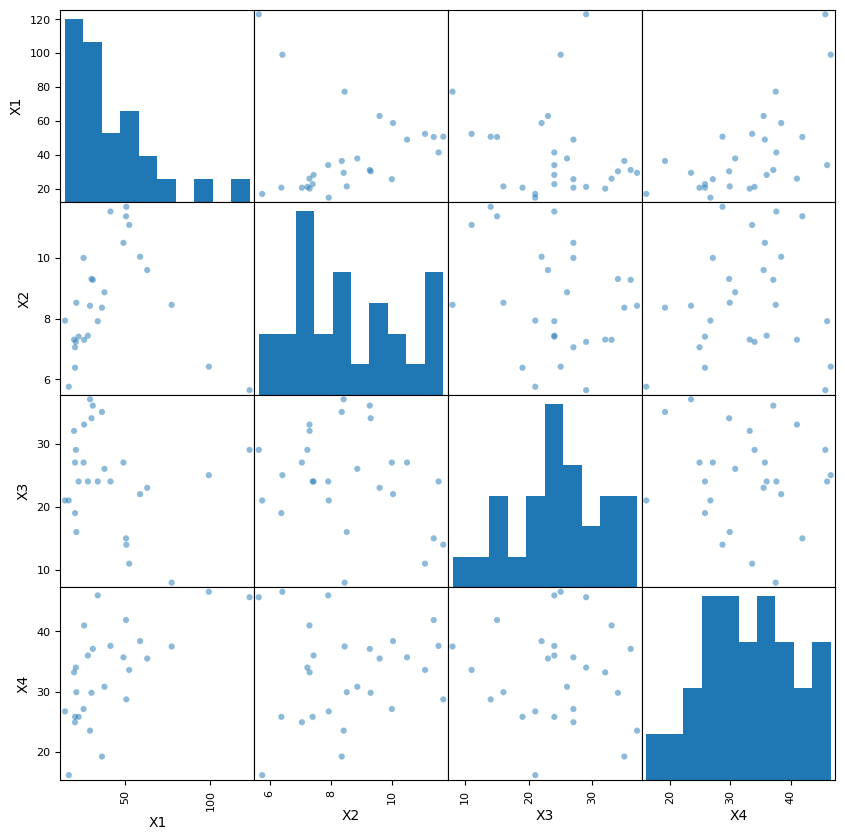

In [145]:
pd.plotting.scatter_matrix(data.drop(columns=['country', 'Y']), figsize=(10, 10), s=80)
plt.show()

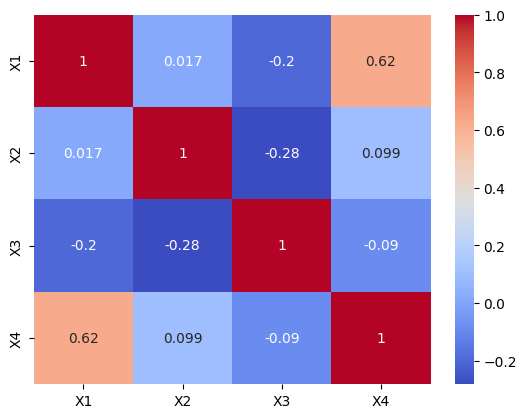

In [146]:
sns.heatmap(data.drop(columns=['country', 'Y']).corr(), annot=True, cmap='coolwarm')
plt.show()

In [147]:
print(data.head())

    country     Y     X1         X2  X3    X4
0  Bulgaria  75.8  14.66   7.933980  21  26.7
1   Czechia  79.9  29.33   8.421847  37  23.5
2   Denmark  81.8  62.91   9.594595  23  35.5
3   Germany  81.1  50.66  11.673909  14  28.7
4   Estonia  79.1  28.08   7.438437  24  36.0


In [148]:
y = data.Y

#### X - macierz zmiennych objaśniających, bez kolumny 'country' i 'Y', ale z logarytmem z 'X1'

In [149]:
data['ln_X1'] = np.log(data['X1'])
X = data[["ln_X1", "X2", "X3", "X4"]].copy()
X = np.asarray(X.values)
y = np.asarray(y).reshape(-1, 1)

t = X.shape[0]
ones = np.ones(t)

X = np.column_stack([ones, X])
beta_head = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(y))
print(beta_head)
print(f'\nB0 = {beta_head[0][0].round(4)}, B1 = {beta_head[1][0].round(4)}, B2 = {beta_head[2][0].round(4)}, B3 = {beta_head[3][0].round(4)}, B4 = {beta_head[4][0].round(4)}')


[[62.12193377]
 [ 3.16898337]
 [ 0.6172219 ]
 [ 0.08320408]
 [ 0.0009251 ]]

B0 = 62.1219, B1 = 3.169, B2 = 0.6172, B3 = 0.0832, B4 = 0.0009


### Wyznaczanie współczynnika zbieżności i determinacji:

#### zmienne do obliczeń: (warto znać)

In [150]:
T = data.shape[0] #Liczba obserwacji
k = X.shape[1] #liczba zmiennych ojaśniających
y_hat = X.dot(beta_head)
#s_2 = 1/(T-k) * (y - y_hat).T.dot(y - y_hat)
# alternatywnie
s_2 = 1/(T-k) * np.sum((y - y_hat)**2)
#lub jeszcze inaczej
#s_2 = 1/(T-k)*(y-X.dot(beta_head)).T.dot(y-X.dot(beta_head))
s = np.sqrt(s_2)

print(f'T = {T}, k = {k}')
print(f's² = {s_2.round(4)}, s = {s.round(4)}')

T = 27, k = 5
s² = 2.8795, s = 1.6969


In [151]:
# Współczynnik zmienności losowej
V = (s / abs(y.mean())) * 100
fi_2 = np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)
r2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)
#lub
# r2 = 1 - fi_2

print(f'V = {V.round(4)}')
print(f'fi² = {fi_2.round(4)}')
print(f'R² = {r2.round(4)}')

V = 2.1019
fi² = 0.3464
R² = 0.6536


In [152]:
from sklearn.metrics import r2_score

# Obliczanie R^2
R2 = r2_score(y, X.dot(beta_head))
print(f"Współczynnik determinacji R^2: {R2}")

Współczynnik determinacji R^2: 0.6536416109458408


### Średnie błędy szacunku parametrów strukturalnych

In [153]:
cov_matrix = s_2 * np.linalg.inv(X.T.dot(X))
print(f'macierz kowariancji:\n{cov_matrix.round(4)}')
print('--------------------------------------------')
var_beta = np.diag(cov_matrix) # wariancje estymatorów beta
se_beta = np.sqrt(var_beta) # odchylenia standardowe estymatorów beta \ średnie błędy szacunku
print(f'odchylenia standardowe estymatorów beta:\n{se_beta.round(4)}')


macierz kowariancji:
[[ 9.8586 -1.3654 -0.3144 -0.0906  0.0004]
 [-1.3654  0.6895 -0.0337  0.0062 -0.0288]
 [-0.3144 -0.0337  0.0415  0.0022  0.0008]
 [-0.0906  0.0062  0.0022  0.0022 -0.0001]
 [ 0.0004 -0.0288  0.0008 -0.0001  0.003 ]]
--------------------------------------------
odchylenia standardowe estymatorów beta:
[3.1398 0.8304 0.2036 0.0468 0.0548]


### Występowanie reszt nietypowych

   country     Y     X1        X2  X3    X4     ln_X1  sztuczna  \
6   Greece  81.8  21.30  8.521534  16  29.9  3.058707         1   
12  Latvia  75.6  21.03  7.236073  29  34.0  3.045950         1   

    reszty_standard  
6          2.197795  
12        -2.014123  


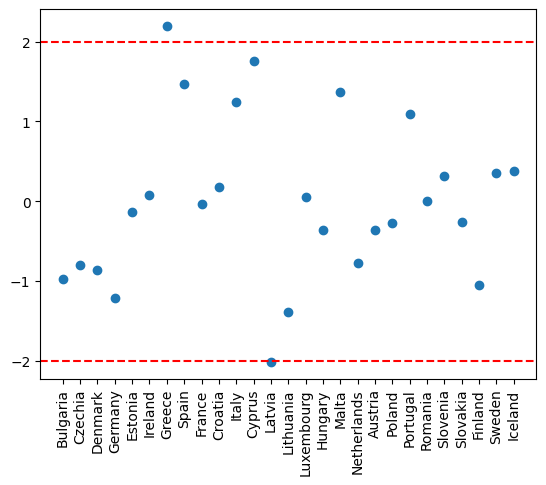

In [154]:
reszty_standard = zscore(y - y_hat)
sztuczna = (np.abs(reszty_standard) > 2).astype(int)

data['sztuczna'] = sztuczna

data['reszty_standard'] = reszty_standard

plt.scatter(data['country'], data['reszty_standard'])
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.xticks(rotation=90)
print(data[data['sztuczna'] == 1])
plt.show()

In [155]:
X = data.drop(columns=['country', 'Y', 'sztuczna', 'reszty_standard', 'X1'])
# ustawiamy kolejność — ln_X1 na początku
X = X[['ln_X1', 'X2', 'X3', 'X4']]

model_1 = linear_regression(X, data.Y)
print(f'Model 1 - R2_corrected: {model_1["R2_corrected"].round(4)}')
print(f'Model 1 - R2: {model_1["R2"].round(4)}')
print(f'Model 1 - s: {model_1["s"].round(3)}')
print(f'Model 1 - V: {model_1["V"].round(3)}')

print('--------------------------------------------')
# model z uwzględnieniem outlierów
model_2 = linear_regression(data.drop(columns=['country', 'Y', 'reszty_standard', 'X1']), data.Y)
print(f'Model 2 - R2_corrected: {model_2["R2_corrected"].round(4)}')
print(f'Model 2 - R2: {model_2["R2"].round(4)}')
print(f'Model 2 - s: {model_2["s"].round(3)}')
print(f'Model 2 - V: {model_2["V"].round(3)}')


Model 1 - R2_corrected: 0.5907
Model 1 - R2: 0.6536
Model 1 - s: [[1.697]]
Model 1 - V: [[2.102]]
--------------------------------------------
Model 2 - R2_corrected: 0.5715
Model 2 - R2: 0.6539
Model 2 - s: [[1.736]]
Model 2 - V: [[2.15]]


### wybieramy model 1, bo ma lepsze parametry jakości dopasowania

In [157]:
c = np.array([0,0.01,1,0,0]).reshape(-1,1)
print(model_1['beta_head'] )
gamma_hat = c.T @ model_1['beta_head']
D_gamma = np.sqrt(c.T.dot(model_1['kow_matrix']).dot(c))
t_gamma = abs(gamma_hat) / D_gamma

print(f'Ocena punktowa gamma: {gamma_hat.round(4)}')
print(f'sredni błąd szacunku: {D_gamma.round(4)}')
print(f'|iloraz t|: {t_gamma.round(4)}')

[[62.1219]
 [ 3.169 ]
 [ 0.6172]
 [ 0.0832]
 [ 0.0009]]
Ocena punktowa gamma: [[0.6489]]
sredni błąd szacunku: [[0.2021]]
|iloraz t|: [[3.2104]]
